<a href="https://colab.research.google.com/github/cjsdudwls1/2026_Spring_Data_Standardization/blob/main/2%EC%A3%BC%EC%B0%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

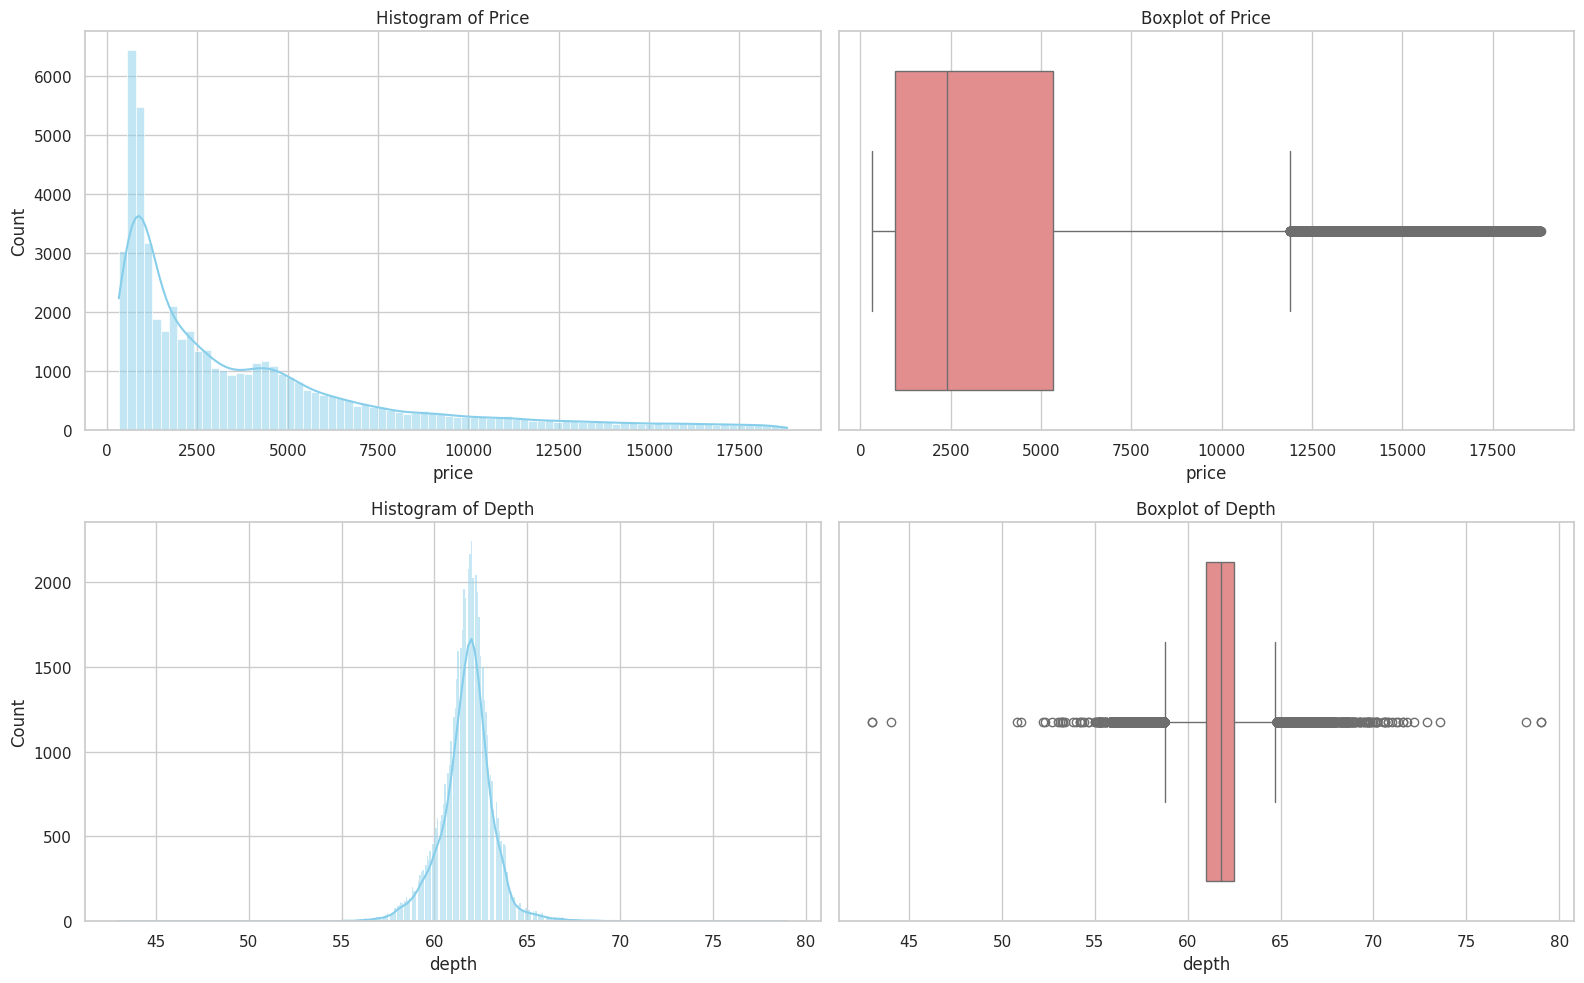

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# 그래프 스타일 설정
sns.set_theme(style='whitegrid')

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Price 히스토그램
sns.histplot(data=diamonds, x='price', kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Histogram of Price')

# Price 박스플롯
sns.boxplot(data=diamonds, x='price', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Boxplot of Price')

# Depth 히스토그램
sns.histplot(data=diamonds, x='depth', kde=True, ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Histogram of Depth')

# Depth 박스플롯
sns.boxplot(data=diamonds, x='depth', ax=axes[1, 1], color='lightcoral')
axes[1, 1].set_title('Boxplot of Depth')

plt.tight_layout()
plt.show()

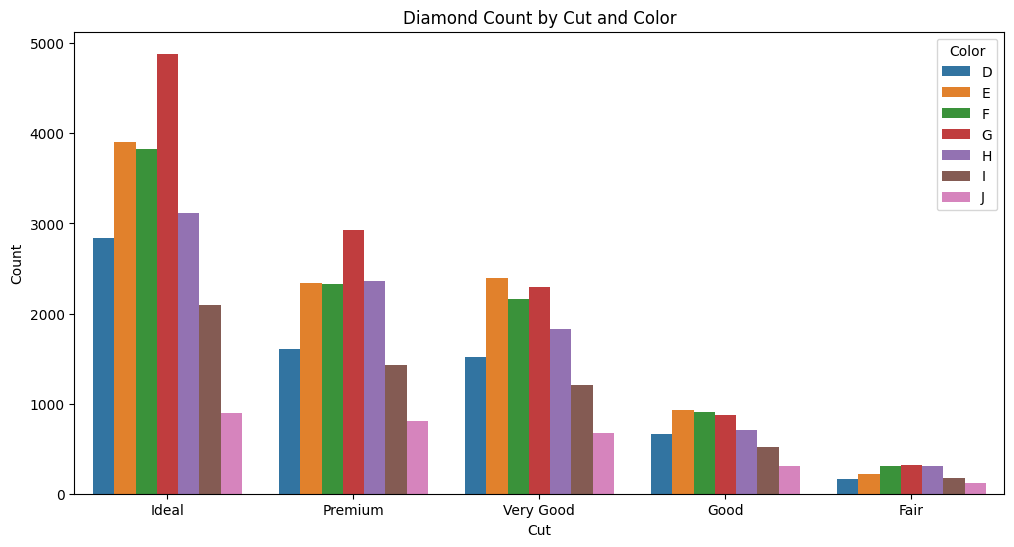

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# 데이터 로드
diamonds = sns.load_dataset('diamonds')

# 그래프 크기 설정
plt.figure(figsize=(12, 6))

# 막대 그래프 그리기
sns.countplot(data=diamonds, x='cut', hue='color')

# 제목 및 라벨 설정
plt.title('Diamond Count by Cut and Color')
plt.xlabel('Cut')
plt.ylabel('Count')
plt.legend(title='Color')
plt.show()

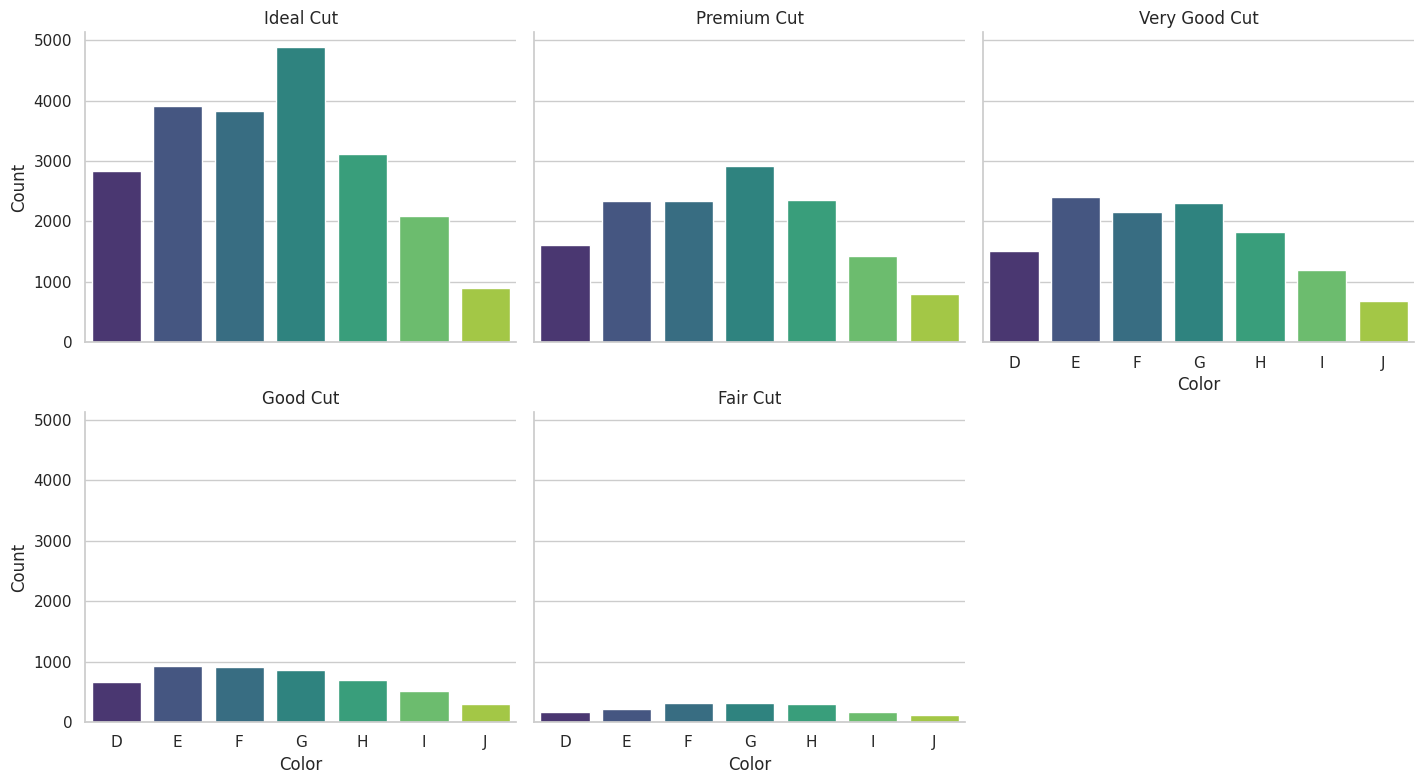

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# FacetGrid를 사용하여 cut별로 그래프 분할
g = sns.FacetGrid(diamonds, col="cut", col_wrap=3, height=4, aspect=1.2)
g.map_dataframe(sns.countplot, x="color", hue="color", palette="viridis", legend=False)

# 레이아웃 조정 및 제목 설정
g.set_axis_labels("Color", "Count")
g.set_titles(col_template="{col_name} Cut")
plt.tight_layout()
plt.show()

In [4]:
!git clone https://github.com/ancestor9/data.git

Cloning into 'data'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 3.20 MiB | 4.47 MiB/s, done.


In [5]:
!ls -R data

data:
combined_df.zip  positions_and_velocities.csv  speed_data.csv
customers.csv	 readme.md
human_data.csv	 seoul_traffic_accidents.csv


In [6]:
import pandas as pd

# 파일 로드
human_df = pd.read_csv('/content/data/human_data.csv')

# 데이터 확인
display(human_df.head())

,Person,height,weight,foot size
0,female,5.71,115.83,6.90
1,female,5.26,103.99,6.06
2,female,5.46,139.57,6.91
3,female,5.59,130.28,7.01
4,male,6.14,179.61,11.83


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Feature(X)와 Target(y) 분리
X = human_df[['height', 'weight', 'foot size']]
y = human_df['Person']

# 2. Train/Test 데이터셋 분리 (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 'preprocessing.StandardScaler()' 대신 이미 import한 'StandardScaler()'를 직접 사용합니다.
scaler = StandardScaler().fit(X_train)

# 결과 확인
print("Mean:", scaler.mean_)
print("Scale:", scaler.scale_)

# 데이터 변환
X_train_scaled = scaler.transform(X_train)
X_train_scaled

Mean: [  5.618125 155.190375   9.30375 ]
Scale: [ 0.27236966 25.02707291  2.06494272]


array([[-0.5438381 , -0.71204392, -1.48369733],
       [ 2.20977252,  0.9741301 ,  0.94252009],
       [ 0.66775057,  1.20348173,  1.07327432],
       [ 1.2184727 ,  0.96094438,  0.37107567],
       [ 1.40204674,  0.70801828,  0.98610483],
       [-1.64528234, -0.40757363, -0.46187722],
       [-0.72741214, -0.8882531 , -0.77665593],
       [ 0.08031364,  0.62450871,  1.10233082],
       [-1.35156388, -0.79675218, -0.55388946],
       [-0.02983078,  0.63090179,  1.51880726],
       [-1.38827868,  0.46068612, -0.17615501],
       [-0.91098618, -1.35534727, -0.83961167],
       [ 0.44746172,  1.37329783,  1.03453233],
       [ 1.43876155,  0.50863419,  0.55994289],
       [ 0.19045807,  0.97612793,  1.35899653],
       [-1.82885638, -0.41556498, -1.17376137],
       [ 0.41074692,  0.74357977,  0.31780543],
       [-0.5805529 , -0.62413911, -1.15923312],
       [-0.13997521, -1.38971006, -0.08414277],
       [ 1.07161346,  1.23265014,  0.46793066],
       [ 1.95276886,  1.07601976,  0.608

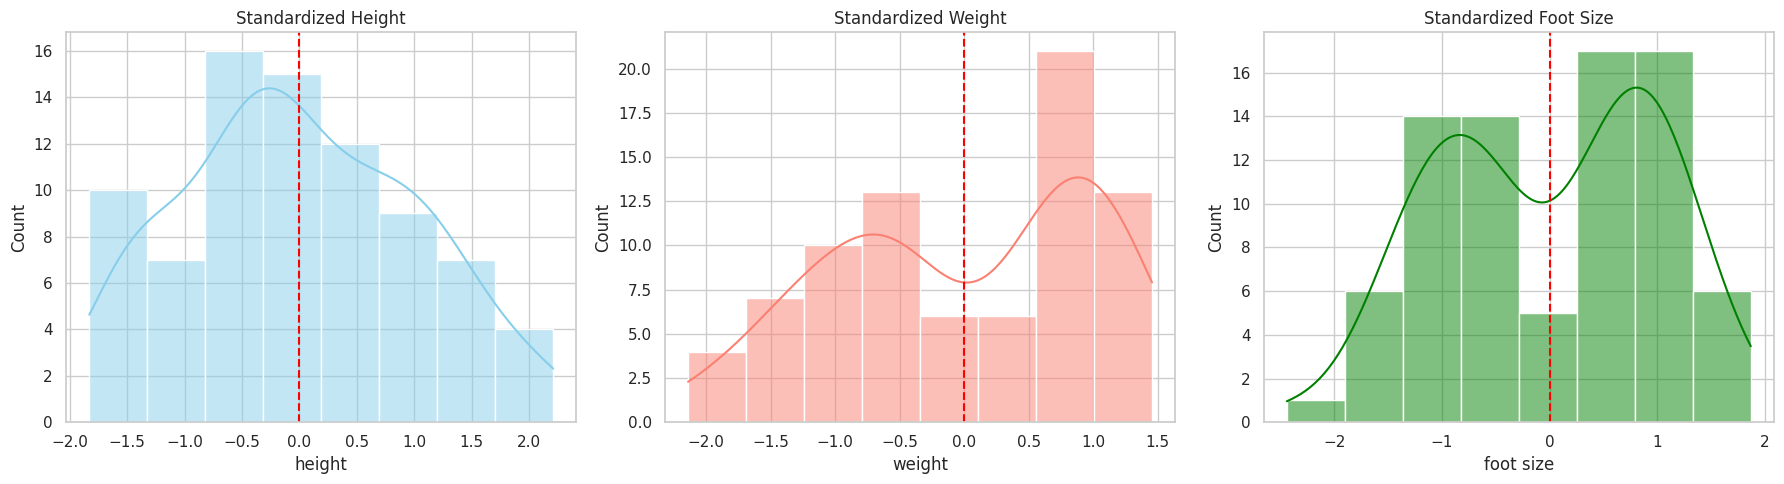

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 표준화된 데이터를 데이터프레임으로 변환
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=['height', 'weight', 'foot size'])

# 1x3 서브플롯 생성
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 각 변수별 히스토그램 시각화
sns.histplot(X_train_scaled_df['height'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Standardized Height')
axes[0].axvline(0, color='red', linestyle='--')

sns.histplot(X_train_scaled_df['weight'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Standardized Weight')
axes[1].axvline(0, color='red', linestyle='--')

sns.histplot(X_train_scaled_df['foot size'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Standardized Foot Size')
axes[2].axvline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

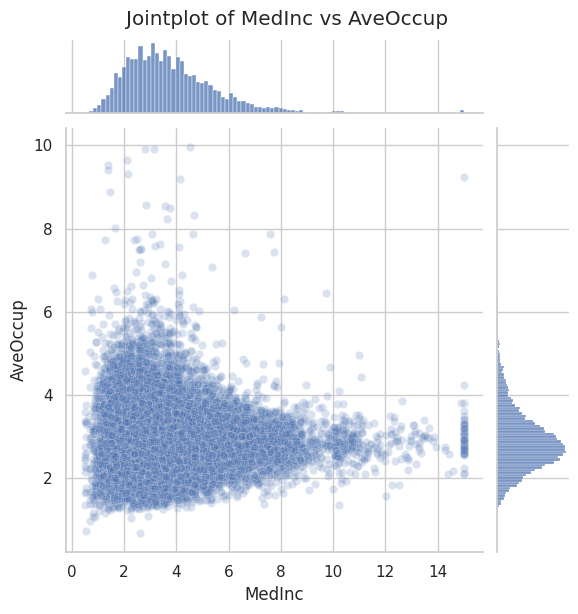

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# 1. 캘리포니아 주택 데이터 불러오기
california = fetch_california_housing()

# 2. 다루기 쉽게 Pandas DataFrame으로 변환하기
df = pd.DataFrame(california.data, columns=california.feature_names)

# 💡 팁: AveOccup(평균 가구원 수) 변수에는 값이 1000이 넘는 극단적인 이상치가 몇 개 섞여 있습니다.
# 그대로 그리면 이상치 때문에 그래프가 심하게 찌그러져서 분포를 알아보기 힘듭니다.
# 그래서 보통 10명 이하인 데이터만 필터링해서 시각화하는 것이 좋습니다.

# 3. 데이터 필터링 (평균 가구원 수가 10명 이하인 데이터만 선택)
df_filtered = df[df['AveOccup'] <= 10]

# 4. jointplot 시각화
# alpha=0.2 옵션을 주어 점들을 반투명하게 만들어 데이터가 겹치는 밀도를 확인하기 쉽게 합니다.
sns.jointplot(x="MedInc", y="AveOccup", data=df_filtered, kind="scatter", alpha=0.2)

# 그래프 제목 추가 (y=1.02는 제목이 그래프와 겹치지 않게 살짝 위로 올리는 설정입니다)
plt.suptitle("Jointplot of MedInc vs AveOccup", y=1.02)

# 그래프 출력
plt.show()

In [24]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib as mpl
import numpy as np
from matplotlib import cm
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    MaxAbsScaler,
    MinMaxScaler,
    Normalizer,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
    StandardScaler,
    minmax_scale,
)

dataset = fetch_california_housing()
X_full, y_full = dataset.data, dataset.target
feature_names = dataset.feature_names

feature_mapping = {
    "MedInc": "Median income in block",
    "HouseAge": "Median house age in block",
    "AveRooms": "Average number of rooms",
    "AveBedrms": "Average number of bedrooms",
    "Population": "Block population",
    "AveOccup": "Average house occupancy",
    "Latitude": "House block latitude",
    "Longitude": "House block longitude",
}

# Take only 2 features to make visualization easier
# Feature MedInc has a long tail distribution.
# Feature AveOccup has a few but very large outliers.
features = ["MedInc", "AveOccup"]
features_idx = [feature_names.index(feature) for feature in features]
X = X_full[:, features_idx]
distributions = [
    ("Unscaled data", X),
    ("Data after standard scaling", StandardScaler().fit_transform(X)),
    ("Data after min-max scaling", MinMaxScaler().fit_transform(X)),
    ("Data after max-abs scaling", MaxAbsScaler().fit_transform(X)),
    (
        "Data after robust scaling",
        RobustScaler(quantile_range=(25, 75)).fit_transform(X),
    ),
    (
        "Data after power transformation (Yeo-Johnson)",
        PowerTransformer(method="yeo-johnson").fit_transform(X),
    ),
    (
        "Data after power transformation (Box-Cox)",
        PowerTransformer(method="box-cox").fit_transform(X),
    ),
    (
        "Data after quantile transformation (uniform pdf)",
        QuantileTransformer(
            output_distribution="uniform", random_state=42
        ).fit_transform(X),
    ),
    (
        "Data after quantile transformation (gaussian pdf)",
        QuantileTransformer(
            output_distribution="normal", random_state=42
        ).fit_transform(X),
    ),
    ("Data after sample-wise L2 normalizing", Normalizer().fit_transform(X)),
]

# scale the output between 0 and 1 for the colorbar
y = minmax_scale(y_full)

# plasma does not exist in matplotlib < 1.5
cmap = getattr(cm, "plasma_r", cm.hot_r)


def create_axes(title, figsize=(16, 6)):
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    # define the axis for the first plot
    left, width = 0.1, 0.22
    bottom, height = 0.1, 0.7
    bottom_h = height + 0.15
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter = plt.axes(rect_scatter)
    ax_histx = plt.axes(rect_histx)
    ax_histy = plt.axes(rect_histy)

    # define the axis for the zoomed-in plot
    left = width + left + 0.2
    left_h = left + width + 0.02

    rect_scatter = [left, bottom, width, height]
    rect_histx = [left, bottom_h, width, 0.1]
    rect_histy = [left_h, bottom, 0.05, height]

    ax_scatter_zoom = plt.axes(rect_scatter)
    ax_histx_zoom = plt.axes(rect_histx)
    ax_histy_zoom = plt.axes(rect_histy)

    # define the axis for the colorbar
    left, width = width + left + 0.13, 0.01

    rect_colorbar = [left, bottom, width, height]
    ax_colorbar = plt.axes(rect_colorbar)

    return (
        (ax_scatter, ax_histy, ax_histx),
        (ax_scatter_zoom, ax_histy_zoom, ax_histx_zoom),
        ax_colorbar,
    )


def plot_distribution(axes, X, y, hist_nbins=50, title="", x0_label="", x1_label=""):
    ax, hist_X1, hist_X0 = axes

    ax.set_title(title)
    ax.set_xlabel(x0_label)
    ax.set_ylabel(x1_label)

    # The scatter plot
    colors = cmap(y)
    ax.scatter(X[:, 0], X[:, 1], alpha=0.5, marker="o", s=5, lw=0, c=colors)

    # Removing the top and the right spine for aesthetics
    # make nice axis layout
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    ax.spines["left"].set_position(("outward", 10))
    ax.spines["bottom"].set_position(("outward", 10))

    # Histogram for axis X1 (feature 5)
    hist_X1.set_ylim(ax.get_ylim())
    hist_X1.hist(
        X[:, 1], bins=hist_nbins, orientation="horizontal", color="grey", ec="grey"
    )
    hist_X1.axis("off")

    # Histogram for axis X0 (feature 0)
    hist_X0.set_xlim(ax.get_xlim())
    hist_X0.hist(
        X[:, 0], bins=hist_nbins, orientation="vertical", color="grey", ec="grey"
    )
    hist_X0.axis("off")

In [25]:
def make_plot(item_idx):
    title, X = distributions[item_idx]
    ax_zoom_out, ax_zoom_in, ax_colorbar = create_axes(title)
    axarr = (ax_zoom_out, ax_zoom_in)
    plot_distribution(
        axarr[0],
        X,
        y,
        hist_nbins=200,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Full data",
    )

    # zoom-in
    zoom_in_percentile_range = (0, 99)
    cutoffs_X0 = np.percentile(X[:, 0], zoom_in_percentile_range)
    cutoffs_X1 = np.percentile(X[:, 1], zoom_in_percentile_range)

    non_outliers_mask = np.all(X > [cutoffs_X0[0], cutoffs_X1[0]], axis=1) & np.all(
        X < [cutoffs_X0[1], cutoffs_X1[1]], axis=1
    )
    plot_distribution(
        axarr[1],
        X[non_outliers_mask],
        y[non_outliers_mask],
        hist_nbins=50,
        x0_label=feature_mapping[features[0]],
        x1_label=feature_mapping[features[1]],
        title="Zoom-in",
    )

    norm = mpl.colors.Normalize(y_full.min(), y_full.max())
    mpl.colorbar.ColorbarBase(
        ax_colorbar,
        cmap=cmap,
        norm=norm,
        orientation="vertical",
        label="Color mapping for values of y",
    )

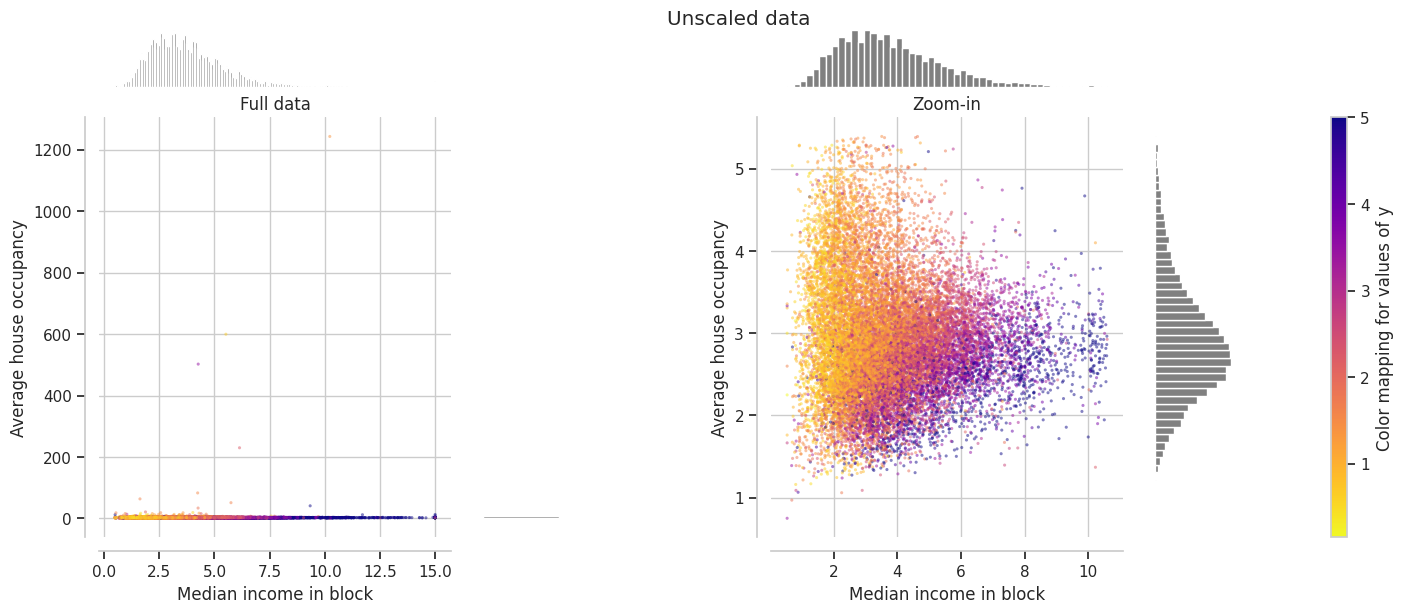

In [26]:
make_plot(0)

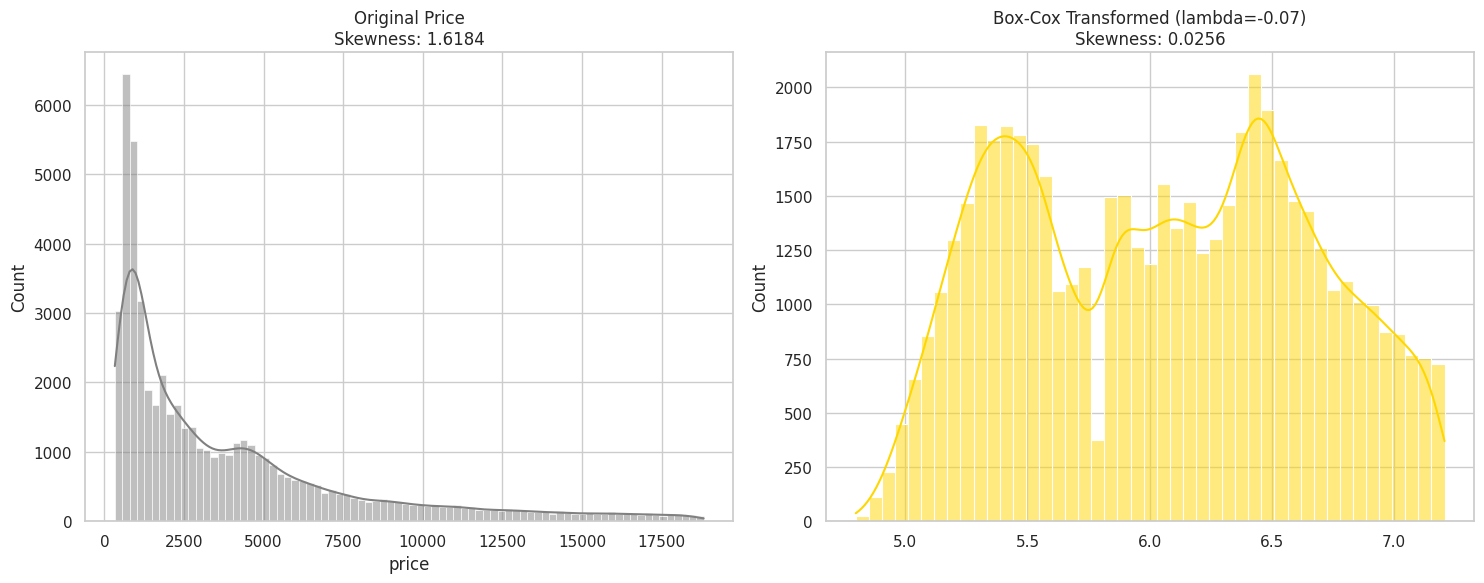

In [28]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 준비
diamonds = sns.load_dataset('diamonds')
price = diamonds['price']

# Box-Cox 변환 수행 (데이터는 양수여야 함)
# lmbda는 최적의 변환 파라미터입니다.
price_boxcox, lmbda = stats.boxcox(price)

# 시각화 설정
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 원본 데이터
sns.histplot(price, kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Original Price\nSkewness: {price.skew():.4f}')

# Box-Cox 변환 데이터
sns.histplot(price_boxcox, kde=True, ax=axes[1], color='gold')
axes[1].set_title(f'Box-Cox Transformed (lambda={lmbda:.2f})\nSkewness: {pd.Series(price_boxcox).skew():.4f}')

plt.tight_layout()
plt.show()

Original Price Skewness: 1.6184


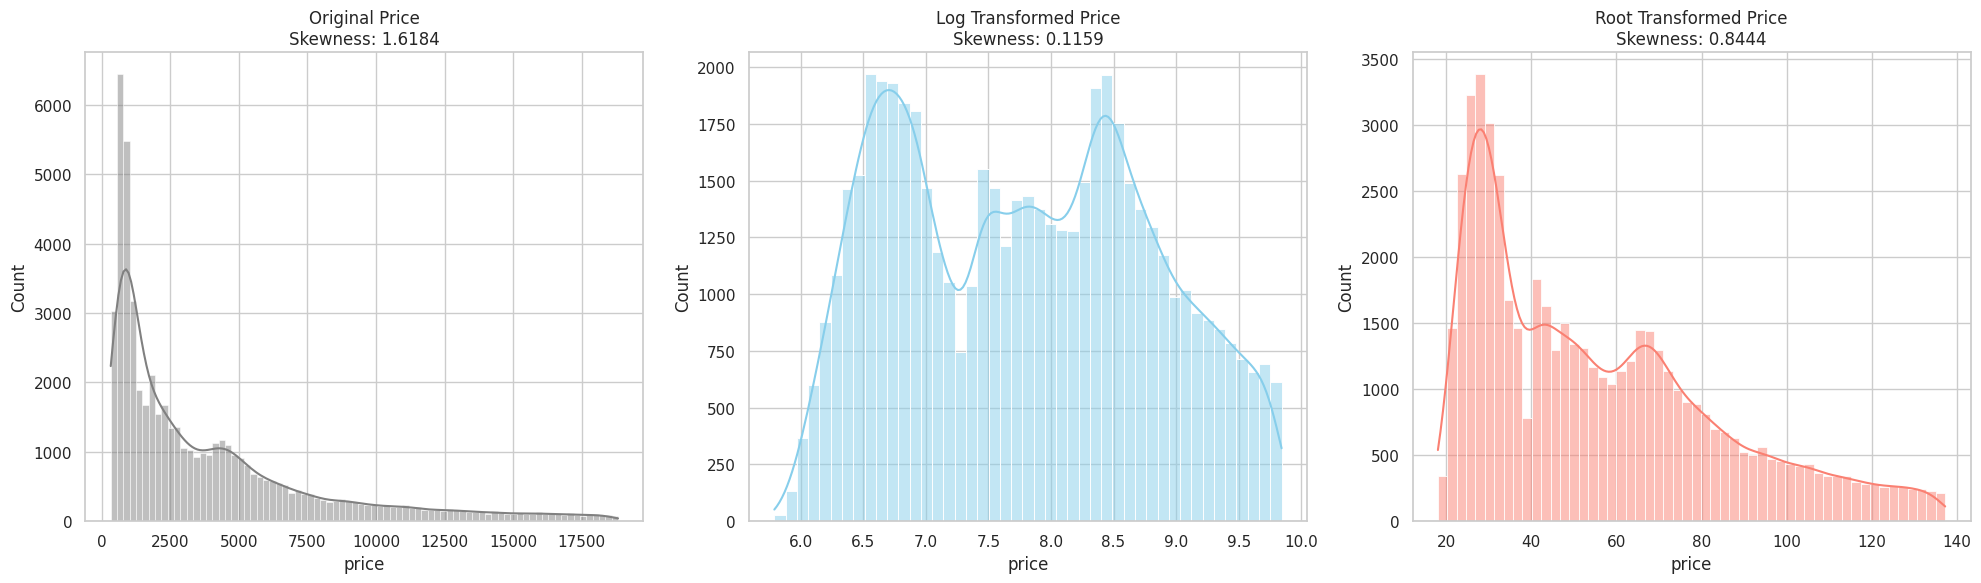

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 데이터 로드
diamonds = sns.load_dataset('diamonds')
price = diamonds['price']

# 1. 원본 데이터 왜도 계산
original_skew = price.skew()
print(f"Original Price Skewness: {original_skew:.4f}")

# 2. 변환 적용
price_log = np.log1p(price) # 로그 변환 (log1p는 log(1+x)로 0 방지)
price_root = np.sqrt(price) # 루트 변환

# 3. 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 원본 데이터 히스토그램
sns.histplot(price, kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Original Price\nSkewness: {original_skew:.4f}')

# 로그 변환 데이터 히스토그램
sns.histplot(price_log, kde=True, ax=axes[1], color='skyblue')
axes[1].set_title(f'Log Transformed Price\nSkewness: {price_log.skew():.4f}')

# 루트 변환 데이터 히스토그램
sns.histplot(price_root, kde=True, ax=axes[2], color='salmon')
axes[2].set_title(f'Root Transformed Price\nSkewness: {price_root.skew():.4f}')

plt.tight_layout()
plt.show()

'Summary Statistics per Series:'

,Series,X_mean,Y_mean,X_var,Y_var,X_std,Y_std,correlation
0,I,9.0,7.500000,11.0,4.132640,3.316625,2.032890,0.816186
1,II,9.0,7.500909,11.0,4.127629,3.316625,2.031657,0.816237
2,III,9.0,7.500000,11.0,4.122620,3.316625,2.030424,0.816287
3,IV,9.0,7.500909,11.0,4.123249,3.316625,2.030579,0.816521


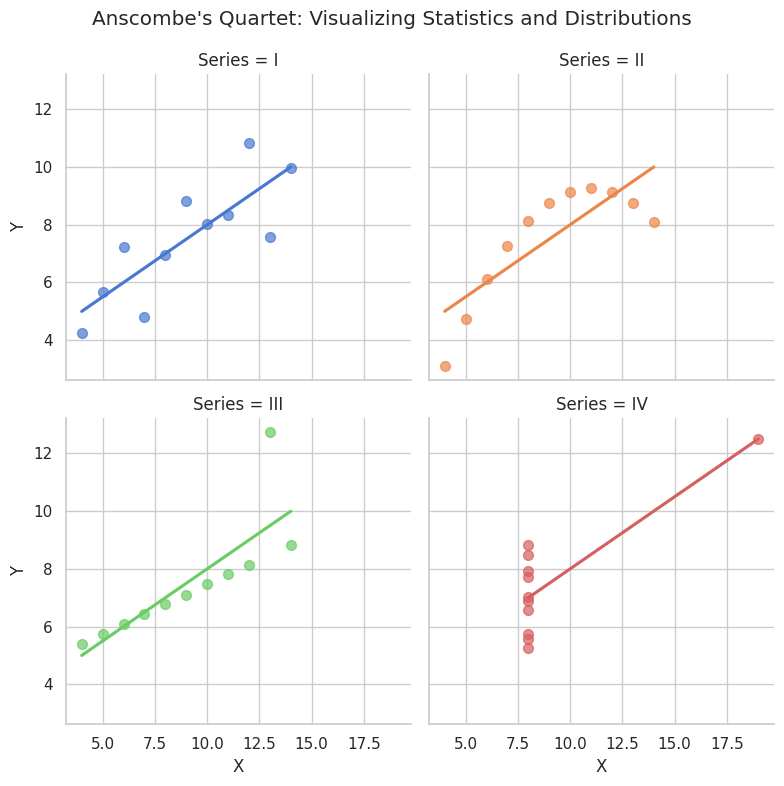

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

# 1. 데이터 로드 (JSON 파일 읽기)
with open('/content/sample_data/anscombe.json', 'r') as f:
    data = json.load(f)
df_anscombe = pd.DataFrame(data)

# 2. 그룹별 통계량 계산 (대문자 'X', 'Y' 사용)
stats_list = []
for series in df_anscombe['Series'].unique():
    group = df_anscombe[df_anscombe['Series'] == series]
    stats = {
        'Series': series,
        'X_mean': group['X'].mean(),
        'Y_mean': group['Y'].mean(),
        'X_var': group['X'].var(),
        'Y_var': group['Y'].var(),
        'X_std': group['X'].std(),
        'Y_std': group['Y'].std(),
        'correlation': group['X'].corr(group['Y'])
    }
    stats_list.append(stats)

df_stats = pd.DataFrame(stats_list)
display("Summary Statistics per Series:", df_stats)

# 3. 시각화 (각 그룹별 산점도와 회귀선)
sns.set_theme(style='whitegrid')
g = sns.lmplot(
    data=df_anscombe, x='X', y='Y', col='Series',
    hue='Series', col_wrap=2, ci=None,
    palette='muted', height=4, scatter_kws={'s': 50, 'alpha': 0.7}
)

g.set_axis_labels('X', 'Y')
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Anscombe's Quartet: Visualizing Statistics and Distributions")
plt.show()

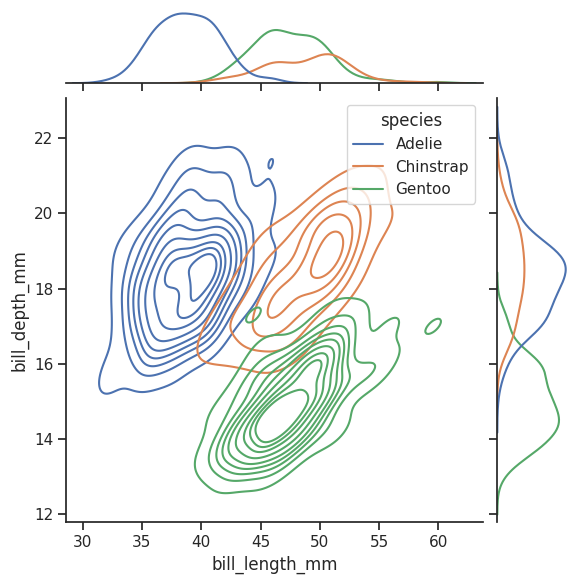

In [32]:
import seaborn as sns
sns.set_theme(style="ticks")

# Load the penguins dataset
penguins = sns.load_dataset("penguins")

# Show the joint distribution using kernel density estimation
g = sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    kind="kde",
)